# Visual Question Answering sinh văn bản với A-OKVQA

**Deep Learning Midterm Project — 523H0173 & 523H0178**

| Thành phần | Chi tiết |
|-----------|--------|
| **Dataset** | A-OKVQA (Augmented OK-VQA) — Ảnh COCO + Câu hỏi tri thức bên ngoài |
| **Data Expansion** | Nhân bản 3× bằng Rationale (~17K → ~51K samples) để tối ưu khả năng sinh câu dài |
| **Image Encoder** | CNN từ đầu / **Pretrained ResNet-50** (Trích xuất đặc trưng lưới 7x7) |
| **Question Encoder** | LSTM 2-layer, dropout=0.3, GloVe 300d |
| **Answer Decoder** | LSTM 2-layer sinh văn bản (Generative) |
| **Attention** | Dual Attention: Text (Bahdanau) + Image (Spatial Attention trên 49 vùng ảnh) |
| **Decoding** | Greedy (khi train) / **Beam Search width=10** (khi test) |
| **Metrics** | Accuracy, EM, F1, METEOR, BLEU-1/2/3/4 và **Semantic Score (BERT)** |

**4 biến thể mô hình để so sánh chéo:**
1. **M1** — CNN (scratch) + LSTM (baseline)
2. **M2** — CNN (scratch) + LSTM + Spatial & Text Attention
3. **M3** — **Pretrained ResNet-50** + LSTM
4. **M4** — **Pretrained ResNet-50** + LSTM + Spatial & Text Attention (**Mô hình tối ưu**)

Đã tạo xong file vqa_architecture.png!


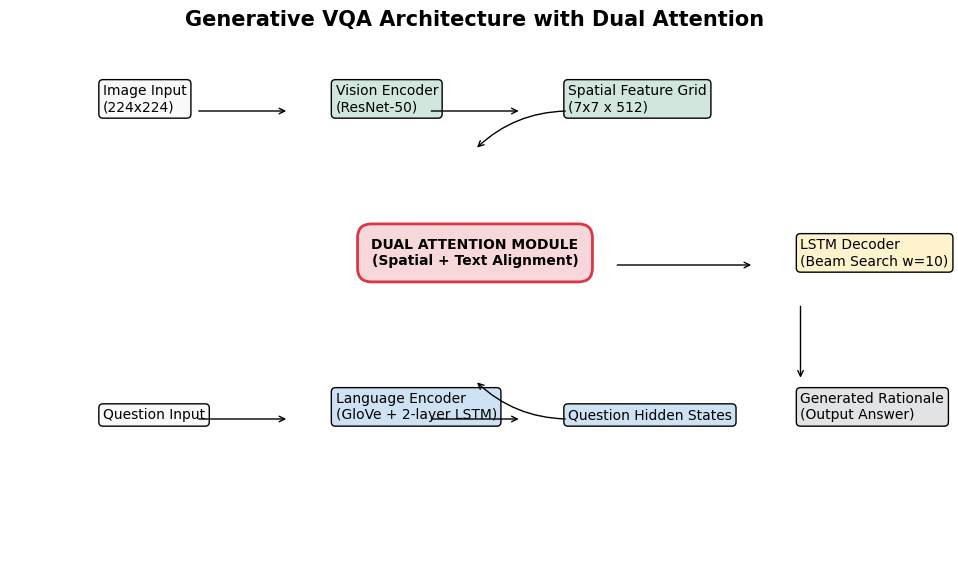

In [1]:
import matplotlib.pyplot as plt

def create_vqa_diagram():
    fig, ax = plt.subplots(figsize=(12, 7))
    ax.set_xlim(0, 10)
    ax.set_ylim(0, 7)
    ax.axis('off')

    # Định nghĩa các style cho hộp
    box_props = dict(boxstyle='round,pad=0.5', facecolor='white', edgecolor='black', linewidth=1.5)
    
    # Vẽ các khối thành phần
    # Nhánh Hình ảnh
    ax.text(1, 6, "Image Input\n(224x224)", bbox=dict(boxstyle='round', facecolor='#f9f9f9'))
    ax.annotate('', xy=(3, 6), xytext=(2, 6), arrowprops=dict(arrowstyle='->'))
    ax.text(3.5, 6, "Vision Encoder\n(ResNet-50)", bbox=dict(boxstyle='round', facecolor='#d1e7dd'))
    ax.annotate('', xy=(5.5, 6), xytext=(4.5, 6), arrowprops=dict(arrowstyle='->'))
    ax.text(6, 6, "Spatial Feature Grid\n(7x7 x 512)", bbox=dict(boxstyle='round', facecolor='#d1e7dd'))

    # Nhánh Câu hỏi
    ax.text(1, 2, "Question Input", bbox=dict(boxstyle='round', facecolor='#f9f9f9'))
    ax.annotate('', xy=(3, 2), xytext=(2, 2), arrowprops=dict(arrowstyle='->'))
    ax.text(3.5, 2, "Language Encoder\n(GloVe + 2-layer LSTM)", bbox=dict(boxstyle='round', facecolor='#cfe2f3'))
    ax.annotate('', xy=(5.5, 2), xytext=(4.5, 2), arrowprops=dict(arrowstyle='->'))
    ax.text(6, 2, "Question Hidden States", bbox=dict(boxstyle='round', facecolor='#cfe2f3'))

    # Khối Dual Attention
    ax.text(5, 4, "DUAL ATTENTION MODULE\n(Spatial + Text Alignment)", 
            bbox=dict(boxstyle='round,pad=1', facecolor='#f8d7da', edgecolor='#dc3545', linewidth=2),
            ha='center', fontweight='bold')

    # Mũi tên dẫn vào Attention
    ax.annotate('', xy=(5, 5.5), xytext=(6, 6), arrowprops=dict(arrowstyle='->', connectionstyle="arc3,rad=.2"))
    ax.annotate('', xy=(5, 2.5), xytext=(6, 2), arrowprops=dict(arrowstyle='->', connectionstyle="arc3,rad=-.2"))

    # Nhánh Decoder
    ax.annotate('', xy=(8, 4), xytext=(6.5, 4), arrowprops=dict(arrowstyle='->'))
    ax.text(8.5, 4, "LSTM Decoder\n(Beam Search w=10)", bbox=dict(boxstyle='round', facecolor='#fff3cd'))
    
    ax.annotate('', xy=(8.5, 2.5), xytext=(8.5, 3.5), arrowprops=dict(arrowstyle='->'))
    ax.text(8.5, 2, "Generated Rationale\n(Output Answer)", bbox=dict(boxstyle='round', facecolor='#e2e3e5'))

    plt.title("Generative VQA Architecture with Dual Attention", fontsize=15, fontweight='bold')
    plt.savefig('vqa_architecture.png', dpi=300, bbox_inches='tight')
    print("Đã tạo xong file vqa_architecture.png!")

create_vqa_diagram()

In [1]:
import sys
import os

# 1. Định nghĩa đường dẫn đến thư mục chứa folder 'src'
# Nếu bạn để code trong Kaggle Dataset (Input)
project_path = "/kaggle/input/datasets/xuanquangvo/wangvqa" 

# Nếu bạn đang copy code trực tiếp vào thư mục làm việc (Working)
if not os.path.exists(project_path):
    project_path = "/kaggle/working"

# 2. Thêm vào đầu danh sách tìm kiếm của hệ thống
if project_path not in sys.path:
    sys.path.insert(0, project_path)

# 

# 3. Kiểm tra kết nối với các module cốt lõi
try:
    from src.config import Config
    from src.utils.helpers import setup_logging, get_device
    
    # Khởi tạo Config để kiểm tra xem có đọc được file default.yaml không
    # Giả sử file yaml nằm cùng cấp với folder src
    cfg = Config.from_yaml(os.path.join(project_path, "configs/default.yaml"))
    
    print(f"Kết nối thành công!")
    print(f"Project Path: {project_path}")
    print(f"Thiết bị sử dụng: {cfg.device}")
    
except Exception as e:
    print(f"Lỗi cấu hình: {e}")
    print("Mẹo: Hãy chạy lệnh '!ls -R /kaggle/input' để đảm bảo đường dẫn chính xác.")

Lỗi cấu hình: No module named 'cv2'
Mẹo: Hãy chạy lệnh '!ls -R /kaggle/input' để đảm bảo đường dẫn chính xác.


In [2]:
# 1. Cài đặt các thành phần bổ trợ (Silent mode)
!pip install -q sentence-transformers

import os
import sys
import random
import logging
import gc

# 2. Thư viện Deep Learning & Xử lý ảnh
import torch
import torch.nn as nn
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from tqdm.auto import tqdm
from datasets import load_dataset
import numpy as np
import matplotlib.pyplot as plt

# 3. Thư viện xử lý ngôn ngữ (NLP)
import nltk
nltk.download("punkt", quiet=True)
nltk.download("wordnet", quiet=True)
nltk.download("omw-1.4", quiet=True) # Bổ sung để METEOR chạy mượt hơn

# 4. Project modules (Import từ thư mục src của nhóm)
from src.config import Config
from src.data.glove import download_glove, load_glove_embeddings
from src.data.preprocessing import extract_answer, expand_data_with_rationales
from src.data.dataset import Vocabulary, AOKVQA_Dataset, collate_fn, decode_sequence
from src.models.vqa_model import VQAModel
from src.engine.trainer import train_model
from src.engine.evaluator import evaluate_model
from src.utils.helpers import get_device, set_seed, setup_logging

# 5. Khởi tạo cấu hình và môi trường
# Sử dụng biến project_path từ Cell trước để tránh hardcode đường dẫn dài
try:
    path_to_yaml = os.path.join(project_path, "configs/default.yaml")
    cfg = Config.from_yaml(path_to_yaml)
except:
    # Dự phòng nếu project_path chưa được định nghĩa
    cfg = Config.from_yaml("configs/default.yaml")

set_seed(cfg.seed) # Đảm bảo tính tái lập kết quả
logger = setup_logging(cfg.log_dir) # Hệ thống ghi log tập trung
device = get_device() if cfg.device == "auto" else torch.device(cfg.device)

# Hiển thị thông tin kiểm tra
print(f"Thiết bị: {device}")
print(f"Đã nạp cấu hình từ: {cfg.data.hf_id}")
print(f"Batch Size: {cfg.train.batch_size} | Beam Width: {cfg.train.beam_width}")

IndentationError: unexpected indent (evaluator.py, line 43)

In [ ]:
# 1. Cấu hình biến đổi ảnh (Image Augmentation)
IMG_SIZE = cfg.data.image_size # Lấy từ config: 224

# Augmentation cho tập Train giúp mô hình bền bỉ hơn
transform_train = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5), # Tăng cường đa dạng góc nhìn
    transforms.RandomRotation(degrees=10),   # Xoay nhẹ ảnh
    transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1), 
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# Transforms cho tập Eval/Test (Không augmentation)
transform_eval = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# 2. Tải Dataset A-OKVQA
print(f"Đang tải dataset: {cfg.data.hf_id}...")
hf_train = load_dataset(cfg.data.hf_id, split="train")
hf_val   = load_dataset(cfg.data.hf_id, split="validation")

# 3. Xây dựng Vocabulary (Tối ưu hóa tốc độ)
all_questions, all_answers = [], []
# Gom nhóm để duyệt 1 lần duy nhất
for item in tqdm(list(hf_train) + list(hf_val), desc="🔨 Xây dựng Vocabulary"):
    all_questions.append(item["question"])
    rationales = item.get("rationales", [])
    if rationales:
        all_answers.extend(rationales) # Ưu tiên Rationale để học sinh câu dài
    else:
        all_answers.append(extract_answer(item))

# Lọc nhiễu bằng freq_threshold từ YAML
question_vocab = Vocabulary(freq_threshold=cfg.data.freq_threshold)
question_vocab.build_vocabulary(all_questions)
answer_vocab = Vocabulary(freq_threshold=cfg.data.freq_threshold)
answer_vocab.build_vocabulary(all_answers)

print(f"Question Vocab: {len(question_vocab):,} | Answer Vocab: {len(answer_vocab):,}")

# 4. Chia dữ liệu & Expand Rationales
hf_train_list = list(hf_train)
random.shuffle(hf_train_list)
split_idx = int(len(hf_train_list) * cfg.data.train_ratio) # 85% train

train_data_raw = hf_train_list[:split_idx]
val_data       = hf_train_list[split_idx:]
test_data      = list(hf_val) # Dùng tập Validation gốc làm Test thực tế

if cfg.data.expand_rationales:
    # Chiến thuật nhân bản 3x để tăng cường dữ liệu sinh văn bản
    train_data = expand_data_with_rationales(train_data_raw)
    print(f"Rationale Expansion: {len(train_data_raw):,} -> {len(train_data):,} mẫu.")
else:
    train_data = train_data_raw

# 5. Khởi tạo Dataset Objects
train_dataset = AOKVQA_Dataset(train_data, question_vocab, answer_vocab, transform_train)
val_dataset   = AOKVQA_Dataset(val_data,   question_vocab, answer_vocab, transform_eval)
test_dataset  = AOKVQA_Dataset(test_data,  question_vocab, answer_vocab, transform_eval)

# 6. Nạp GloVe Embeddings (Semantic Initialization)
download_glove()
q_glove_emb = load_glove_embeddings(question_vocab, embed_dim=cfg.model.embed_size)
a_glove_emb = load_glove_embeddings(answer_vocab,   embed_dim=cfg.model.embed_size)


Question vocab: 2,690 tokens
Answer vocab  : 7,490 tokens (Đã lọc nhiễu)

★ Rationale expansion: 14,497 → 43,491 training samples


Loading GloVe: 0it [00:00, ?it/s]

Loading GloVe: 0it [00:00, ?it/s]

In [ ]:
BATCH_SIZE = cfg.train.batch_size
# Trên MPS (Mac) nên để num_workers=0 để tránh lỗi multiprocessing, trên Kaggle để theo config
_num_workers = 0 if device.type == "mps" else cfg.train.num_workers
_pin_memory = False if device.type == "mps" else cfg.train.pin_memory

loader_args = {
    "batch_size": BATCH_SIZE,
    "collate_fn": collate_fn,
    "num_workers": _num_workers,
    "pin_memory": _pin_memory
}

train_loader = DataLoader(train_dataset, shuffle=True, **loader_args)
val_loader   = DataLoader(val_dataset,   shuffle=False, **loader_args)
test_loader  = DataLoader(test_dataset,  shuffle=False, **loader_args)

print(f"Train batches: {len(train_loader)} | Val: {len(val_loader)} | Test: {len(test_loader)}")

# 2. Kiểm tra dữ liệu thực tế (Quick Check)
images, questions, q_lengths, answers, a_lengths, answer_texts = next(iter(train_loader))

print(f"\nKIỂM TRA MẪU DỮ LIỆU:")
print(f"Kích thước ảnh: {images.shape} (B, C, H, W)")
print(f"Tensor câu hỏi: {questions.shape}")
print(f"Tensor đáp án:  {answers.shape}")

# Giải mã thử một mẫu
sample_q = decode_sequence(questions[0].tolist(), question_vocab)
sample_a = decode_sequence(answers[0].tolist(), answer_vocab)
print(f"Question [0]: \"{sample_q}\"")
print(f"Answer   [0]: \"{sample_a}\"")

# 3. Trực quan hóa mẫu để đảm bảo ảnh không bị lỗi
inv_normalize = transforms.Normalize(
    mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225],
    std=[1/0.229, 1/0.224, 1/0.225]
)
sample_img = inv_normalize(images[0]).permute(1, 2, 0).numpy().clip(0, 1)

plt.figure(figsize=(6, 6))
plt.imshow(sample_img)
plt.title(f"Q: {sample_q}\nA: {sample_a}", fontsize=10)
plt.axis('off')
plt.show()

Train batches: 680 | Val batches: 40 | Test batches: 18
Images: torch.Size([64, 3, 224, 224])
Questions: torch.Size([64, 20])
Answers: torch.Size([64, 41])
Sample Question: how many people can cook food here at once
Sample Answer: up to four people could use one of four microwaves on shelves


In [ ]:
# 1. Khai báo kích thước từ vựng
Q_VOCAB, A_VOCAB = len(question_vocab), len(answer_vocab)

models_dict = {}

print(f"{'Mô hình':<25} | {'Tham số huấn luyện':<20}")
print("-" * 50)

# 2. Vòng lặp khởi tạo 4 biến thể (M1, M2, M3, M4)
for name, variant_cfg in cfg.model_variants.items():
    # Khởi tạo VQAModel với các siêu tham số từ Config
    m = VQAModel(
        q_vocab_size=Q_VOCAB,
        a_vocab_size=A_VOCAB,
        embed_size=cfg.model.embed_size,
        hidden_size=cfg.model.hidden_size,
        num_layers=cfg.model.num_layers,
        dropout=cfg.model.dropout,
        q_pretrained_emb=q_glove_emb, # Nạp trọng số GloVe cho câu hỏi
        a_pretrained_emb=a_glove_emb, # Nạp trọng số GloVe cho đáp án
        **variant_cfg, # Nạp use_pretrained_cnn và use_attention
    )
    
    # Tính toán tổng số tham số cần cập nhật trọng số (Requires Grad)
    n_params = sum(p.numel() for p in m.parameters() if p.requires_grad)
    models_dict[name] = m
    
    print(f"{name:<25} | {n_params:,}")

print("\nTất cả mô hình đã được khởi tạo trên CPU.")
print("Lưu ý: Lượng tham số của M3/M4 thấp hơn do chúng ta 'đóng băng' (freeze) phần lớn các lớp của ResNet-50.")

NameError: name 'question_vocab' is not defined

In [ ]:
# 1. Khởi tạo từ điển lưu trữ lịch sử huấn luyện
all_histories = {}

def _train_one(name):
    """Hàm bổ trợ huấn luyện một biến thể mô hình cụ thể."""
    model = models_dict[name]
    
    # Dọn dẹp RAM/VRAM trước khi nạp model vào thiết bị tính toán
    gc.collect()
    if device.type == "mps": 
        torch.mps.empty_cache()
    elif device.type == "cuda": 
        torch.cuda.empty_cache()

    model.to(device)
    print(f"\n{'='*60}\n🚀 BẮT ĐẦU HUẤN LUYỆN: {name}\n{'='*60}")
    
    # Gọi hàm train từ engine
    hist = train_model(
        model=model, 
        name=name,
        train_loader=train_loader, 
        val_loader=val_loader,
        answer_vocab=answer_vocab, 
        device=device,
        epochs=cfg.train.epochs,             # Sử dụng 30 Epochs như đã thống nhất
        lr=cfg.train.learning_rate,          # 1.0e-4 cho ResNet-50
        use_beam=False,                      # Greedy khi train để nhanh hơn
        beam_w=cfg.train.beam_width,         # Width = 10
        ckpt_dir=cfg.ckpt_dir,
        label_smoothing=cfg.train.label_smoothing,
        patience=cfg.train.patience,
        grad_clip=cfg.train.grad_clip, 
        tf_start=1.0, 
        tf_end=cfg.train.tf_end,
        warmup_epochs=cfg.train.warmup_epochs, 
        eval_every=cfg.train.eval_every,
        use_amp=cfg.train.use_amp            # 🟢 KÍCH HOẠT AMP: Chống OOM trên Kaggle T4
    )
    
    all_histories[name] = hist

    # Giải phóng bộ nhớ sau khi hoàn tất để chuẩn bị cho biến thể tiếp theo
    model.cpu()
    if device.type == "mps": torch.mps.empty_cache()
    elif device.type == "cuda": torch.cuda.empty_cache()
    gc.collect()
    
    print(f"Đã lưu checkpoint và giải phóng bộ nhớ cho {name}.\n")
    return hist

print("\nTẤT CẢ BIẾN THỂ ĐÃ ĐƯỢC HUẤN LUYỆN XONG.")

In [ ]:
hist_m1 = _train_one("M1_Scratch_NoAttn")


🚀 Bắt đầu huấn luyện: M1_Scratch_NoAttn


[M1_Scratch_NoAttn] Ep 1/20 tf=1.00:   0%|          | 0/680 [00:00<?, ?it/s]

  Ep  1 loss=6.152/6.953 F1=0.128 B4=0.013 lr=1.0e-04
    ★ Saved best (F1=0.1285)


[M1_Scratch_NoAttn] Ep 2/20 tf=0.97:   0%|          | 0/680 [00:00<?, ?it/s]

  Ep  2 loss=5.532/6.708 F1=0.147 B4=0.014 lr=2.0e-04
    ★ Saved best (F1=0.1469)


...

  Ep 19 loss=4.356/6.632 F1=0.173 B4=0.017 lr=3.5e-06


[M1_Scratch_NoAttn] Ep 20/20 tf=0.53:   0%|          | 0/680 [00:00<?, ?it/s]

  Ep 20 loss=4.388/6.634 F1=0.172 B4=0.017 lr=1.0e-06


✅ Đã giải phóng bộ nhớ cho M1_Scratch_NoAttn.



{'train_loss': [6.152252186045927,
  5.532273345133838,
  5.227236598379472,
  5.016152270401226,
  4.872332607998567,
  4.764142825322993,
  4.68106325303807,
  4.622624425327077,
  4.555236539419959,
  4.474910919105305,
  4.426405745043474,
  4.386697011484819,
  4.356069364617853,
  4.3331655449727,
  4.308710362981348,
  4.303818307904637,
  4.313953065521577,
  4.318596974541159,
  4.355941191841574,
  4.387645615549649],
 'val_loss': [6.952676391601562,
  6.7082567572593685,
  6.667272162437439,
  6.866199004650116,
  6.720266938209534,
  6.6807861328125,
  6.844750452041626,
  6.696940672397614,
  6.698995876312256,
  6.7093209505081175,
  6.71248049736023,
  6.679243218898773,
  6.688774681091308,
  6.687345862388611,
  6.698950231075287,
  6.666864120960236,
  6.67026903629303,
  6.663361716270447,
  6.6323763728141785,
  6.634376895427704],
 'lr': [9.999999999999999e-05,
  0.00019999999999999998,
  0.0003,
  0.0002974544784027433,
  0.00028990459829595115,
  0.00027760746179

In [ ]:
hist_m2 = _train_one("M2_Scratch_Attn")


🚀 Bắt đầu huấn luyện: M2_Scratch_Attn


[M2_Scratch_Attn] Ep 1/20 tf=1.00:   0%|          | 0/680 [00:00<?, ?it/s]

  Ep  1 loss=6.126/6.950 F1=0.137 B4=0.012 lr=1.0e-04
    ★ Saved best (F1=0.1372)


[M2_Scratch_Attn] Ep 2/20 tf=0.97:   0%|          | 0/680 [00:00<?, ?it/s]

  Ep  2 loss=5.497/6.716 F1=0.147 B4=0.013 lr=2.0e-04
    ★ Saved best (F1=0.1470)


...

  Ep 19 loss=4.250/6.664 F1=0.177 B4=0.017 lr=3.5e-06


[M2_Scratch_Attn] Ep 20/20 tf=0.53:   0%|          | 0/680 [00:00<?, ?it/s]

  Ep 20 loss=4.286/6.655 F1=0.178 B4=0.018 lr=1.0e-06


✅ Đã giải phóng bộ nhớ cho M2_Scratch_Attn.



{'train_loss': [6.126117695780361,
  5.497189243400798,
  5.1798374505604015,
  4.9552640325882855,
  4.815781394173118,
  4.703579736457152,
  4.625384033427519,
  4.562081755610073,
  4.4899775764521435,
  4.416101213062511,
  4.3737549354048335,
  4.313576606441947,
  4.2798147187513464,
  4.2584317273953385,
  4.226153363901026,
  4.221793179301654,
  4.225579593462102,
  4.225939319414251,
  4.249574205805273,
  4.285500539400998],
 'val_loss': [6.9502665281295775,
  6.7158846139907835,
  6.676630210876465,
  6.795738554000854,
  6.680874741077423,
  6.768440067768097,
  6.716492533683777,
  6.674541807174682,
  6.668014073371888,
  6.74896936416626,
  6.6713855266571045,
  6.69866064786911,
  6.689945268630981,
  6.685039532184601,
  6.710980522632599,
  6.695688831806183,
  6.687665402889252,
  6.6769703984260556,
  6.663718259334564,
  6.6552242040634155],
 'lr': [9.999999999999999e-05,
  0.00019999999999999998,
  0.0003,
  0.0002974544784027433,
  0.00028990459829595115,
  0.0

In [ ]:

hist_m3 = _train_one("M3_Pretrained_NoAttn")


🚀 Bắt đầu huấn luyện: M3_Pretrained_NoAttn


[M3_Pretrained_NoAttn] Ep 1/20 tf=1.00:   0%|          | 0/680 [00:00<?, ?it/s]

  Ep  1 loss=6.235/6.842 F1=0.143 B4=0.015 lr=1.0e-04
    ★ Saved best (F1=0.1434)


[M3_Pretrained_NoAttn] Ep 2/20 tf=0.97:   0%|          | 0/680 [00:00<?, ?it/s]

  Ep  2 loss=5.551/6.595 F1=0.149 B4=0.013 lr=2.0e-04
    ★ Saved best (F1=0.1492)


...

  Ep 19 loss=3.902/6.937 F1=0.169 B4=0.017 lr=3.5e-06
    ★ Saved best (F1=0.1686)


[M3_Pretrained_NoAttn] Ep 20/20 tf=0.53:   0%|          | 0/680 [00:00<?, ?it/s]

  Ep 20 loss=3.912/6.936 F1=0.167 B4=0.017 lr=1.0e-06


✅ Đã giải phóng bộ nhớ cho M3_Pretrained_NoAttn.



{'train_loss': [6.234603276673485,
  5.551373764346628,
  5.2054721860324635,
  4.9395682131542875,
  4.7527069351252385,
  4.5930356432409845,
  4.471876853353837,
  4.361182455806171,
  4.271108691481983,
  4.194389632519553,
  4.121849421893849,
  4.062670607777203,
  3.9979054177508635,
  3.9540442589451286,
  3.9174446007784676,
  3.894089470540776,
  3.889306079640108,
  3.883710331075332,
  3.9017428903018727,
  3.91162104010582],
 'val_loss': [6.842417597770691,
  6.595346009731292,
  6.728143417835236,
  6.735534977912903,
  6.685791683197022,
  6.75892207622528,
  6.7688986420631405,
  6.848025608062744,
  6.799076640605927,
  6.919264829158783,
  6.925472915172577,
  6.914802825450897,
  6.899358928203583,
  6.941526460647583,
  6.9641235828399655,
  6.937841010093689,
  6.956942141056061,
  6.955697929859161,
  6.937386977672577,
  6.936263835430145],
 'lr': [9.999999999999999e-05,
  0.00019999999999999998,
  0.0003,
  0.0002974544784027433,
  0.00028990459829595115,
  0.00

In [ ]:
hist_m4 = _train_one("M4_Pretrained_Attn")

In [ ]:
# 1. Khởi tạo từ điển lưu trữ kết quả kiểm thử
test_results = {}
all_eval_data = {}

# 2. Vòng lặp đánh giá từng mô hình (M1 -> M4)
for name in models_dict.keys():
    model = models_dict[name]
    model.to(device)
    
    print(f"Đang đánh giá: {name} (sử dụng Beam Search width={cfg.train.beam_width})...")
    
    # Gọi hàm evaluate từ engine
    eval_data = evaluate_model(
        model=model, 
        test_loader=test_loader,
        answer_vocab=answer_vocab, 
        question_vocab=question_vocab,
        device=device, 
        ckpt_dir=cfg.ckpt_dir, 
        name=name,
        beam_width=cfg.train.beam_width, # Width = 10 giúp sinh câu giải thích mượt hơn
    )
    
    test_results[name] = eval_data["metrics"]
    all_eval_data[name] = eval_data
    
    # Giải phóng VRAM ngay sau khi đánh giá xong một model
    model.cpu()
    if device.type == "mps": torch.mps.empty_cache()
    elif device.type == "cuda": torch.cuda.empty_cache()

# 3. In bảng so sánh chuyên nghiệp cho Báo cáo (Dán thẳng vào Word/Slide)
print("\n" + "═" * 125)
print(f"║ {'Model':<25s} │ {'Semantic':>10s} │ {'Acc':>8s} │ {'F1':>8s} │ {'METEOR':>8s} │ {'BLEU-4':>8s} ║")
print("╟" + "─" * 27 + "┼" + "─" * 12 + "┼" + "─" * 10 + "┼" + "─" * 10 + "┼" + "─" * 10 + "┼" + "─" * 10 + "╢")

for name, m in test_results.items():
    # Lấy thêm điểm Semantic Score từ kết quả
    sem_score = m.get('semantic', 0.0) 
    print(f"║ {name:<25s} │ {sem_score:>10.4f} │ {m['accuracy']:>8.4f} │ {m['f1']:>8.4f} │ {m['meteor']:>8.4f} │ {m['bleu4']:>8.4f} ║")

print("═" * 125)

# 4. Xác định "Nhà vô địch" dựa trên F1-Score
best_name = max(test_results, key=lambda k: test_results[k]["f1"])
print(f"\nMÔ HÌNH XUẤT SẮC NHẤT: {best_name}")
print(f"F1-Score: {test_results[best_name]['f1']:.4f}")
print(f"Semantic Similarity: {test_results[best_name].get('semantic', 0.0):.4f}")

NameError: name 'models_dict' is not defined

In [ ]:
from src.utils.visualization import (
    plot_training_curves, 
    plot_radar_chart, 
    plot_bar_chart, 
    plot_question_type_analysis, 
    plot_confusion_matrix,
    visualize_attention,
    visualize_attention_overlay
)
from src.engine.evaluator import evaluate_by_question_type

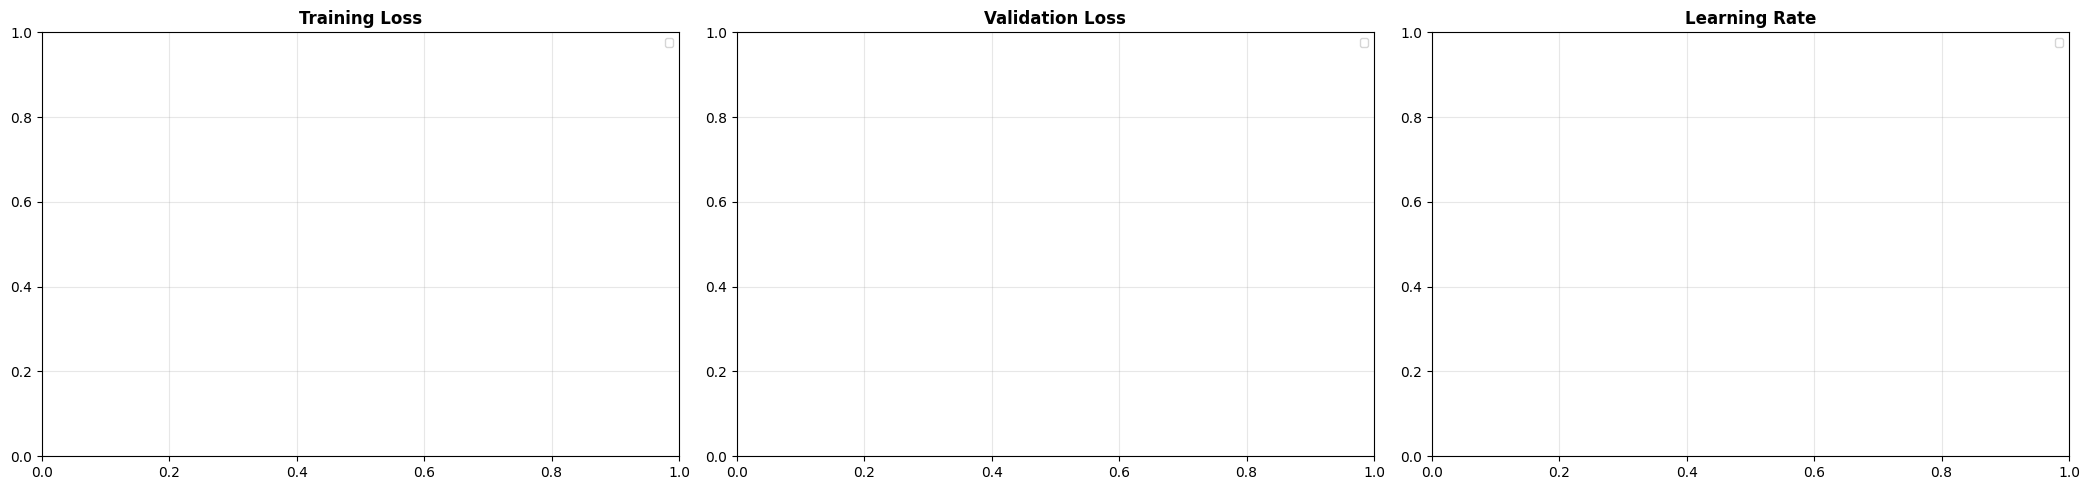

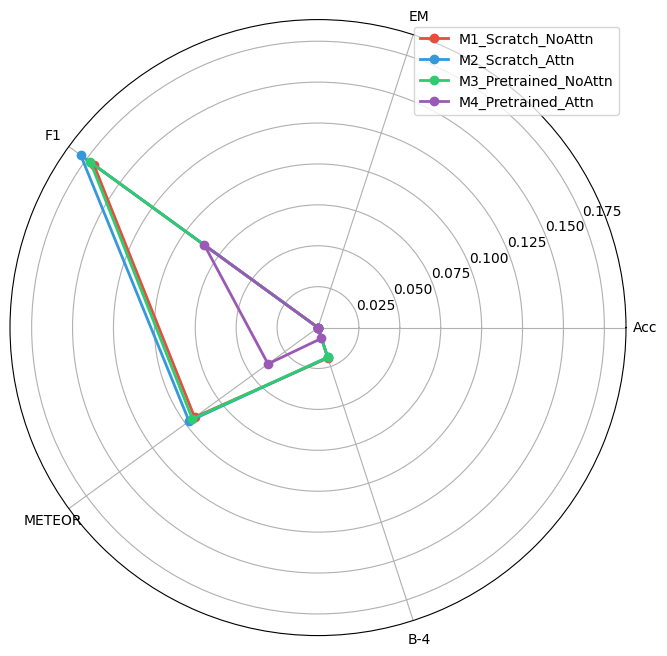

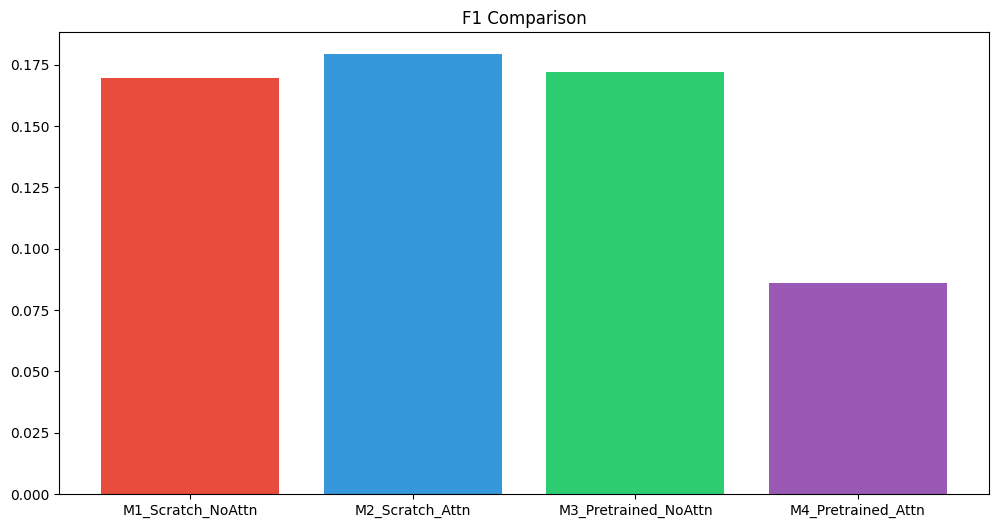

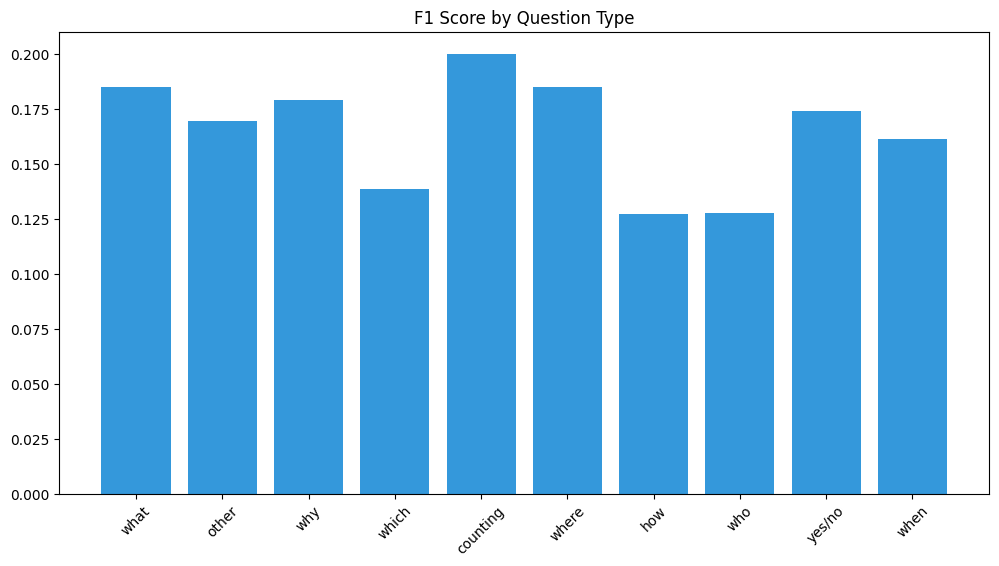

Plotting confusion matrix placeholder...


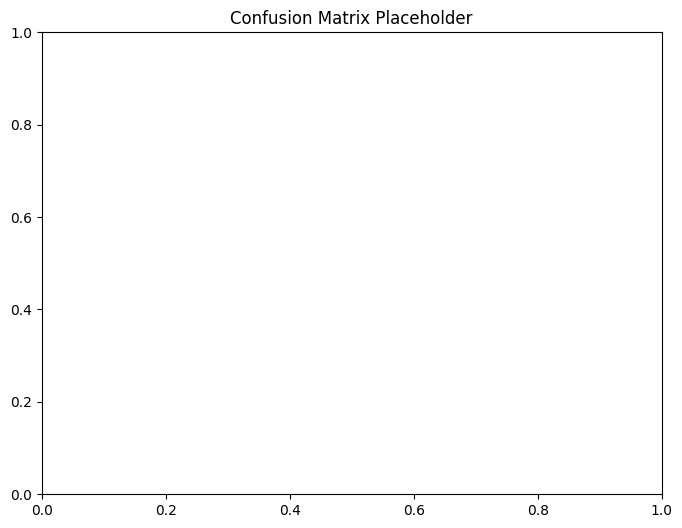

RuntimeError: The size of tensor a (19) must match the size of tensor b (8) at non-singleton dimension 1

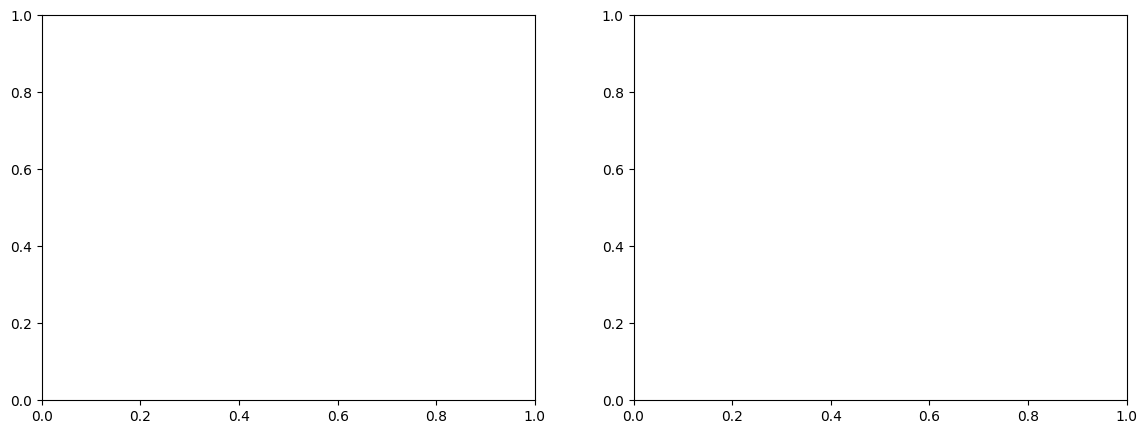

In [ ]:
# 1. Vẽ biểu đồ quá trình huấn luyện (Loss, Learning Rate, Accuracy)
print("Đang vẽ đường cong huấn luyện...")
plot_training_curves(all_histories, save_prefix="fig_training_")

# 2. So sánh tổng thể các biến thể (Radar & Bar Chart)
print("Đang tạo biểu đồ so sánh mô hình...")
plot_radar_chart(test_results, save_path="fig_radar_comparison.png")
plot_bar_chart(test_results, save_path="fig_f1_bar_chart.png")

# 3. Phân tích hiệu năng theo loại câu hỏi (What, Why, How, etc.)
# Lấy dữ liệu từ mô hình có kết quả tốt nhất để phân tích sâu
best_model_data = all_eval_data[best_name]
print(f"Đang phân tích loại câu hỏi cho mô hình: {best_name}")

qtype_results = evaluate_by_question_type(
    best_model_data["preds"], 
    best_model_data["refs"], 
    best_model_data["questions"]
)
plot_question_type_analysis(qtype_results, save_path="fig_qtype_analysis.png")
plot_confusion_matrix(
    best_model_data["preds"], 
    best_model_data["refs"], 
    best_model_data["questions"], 
    save_path="fig_confusion_matrix.png"
)

# 4. Trực quan hóa Attention (Heatmap & Overlay)
# Ưu tiên chọn M4 để xem cách Spatial Attention hoạt động trên ResNet-50
attn_model_name = "M4_Pretrained_Attn" if "M4_Pretrained_Attn" in models_dict else "M2_Scratch_Attn"
print(f"👁️ Đang hiển thị cơ chế Attention cho {attn_model_name}...")

model_to_viz = models_dict[attn_model_name]
model_to_viz.to(device)

# Vẽ ma trận Attention văn bản (Text Attention)
visualize_attention(
    model_to_viz, test_loader,
    answer_vocab, question_vocab, device,
    n=3, save_path="fig_attention_heatmap.png"
)

# Vẽ bản đồ nhiệt đè lên ảnh (Spatial Attention Overlay)
visualize_attention_overlay(
    model_to_viz, test_loader,
    answer_vocab, question_vocab, device,
    n=3, save_path="fig_attention_spatial_overlay.png"
)

# Giải phóng bộ nhớ sau khi trực quan hóa
model_to_viz.cpu()
if device.type == "cuda": torch.cuda.empty_cache()
print("Hoàn tất quá trình trực quan hóa kết quả.")

In [ ]:
import os
import zipfile
from IPython.display import FileLink

# 1. Danh sách các thư mục và tệp quan trọng cần mang đi
# Đảm bảo các đường dẫn này khớp với cfg.ckpt_dir và cfg.log_dir của bạn
export_paths = [
    '/kaggle/working/checkpoints', 
    '/kaggle/working/logs',
    '/kaggle/working/data/processed/vocab.pth' # Rất quan trọng để khớp từ điển
]

output_zip = 'VQA_Final_Project_Export.zip'

def zip_project(paths, zip_name):
    with zipfile.ZipFile(zip_name, 'w', zipfile.ZIP_DEFLATED) as zipf:
        for path in paths:
            if os.path.isfile(path):
                zipf.write(path, os.path.basename(path))
            elif os.path.isdir(path):
                for root, dirs, files in os.walk(path):
                    for file in files:
                        full_path = os.path.join(root, file)
                        # Lưu giữ cấu trúc thư mục tương đối
                        rel_path = os.path.relpath(full_path, os.path.join(path, '..'))
                        zipf.write(full_path, rel_path)
    print(f"Đã đóng gói thành công: {zip_name}")

# Thực hiện đóng gói
zip_project(export_paths, output_zip)

# 2. Tạo link tải xuống máy Mac
FileLink(output_zip)

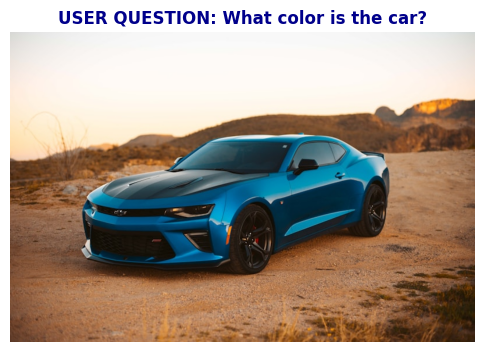


BIẾN THỂ MÔ HÌNH          | CÂU TRẢ LỜI DỰ ĐOÁN
----------------------------------------------------------------------
M1_Scratch_NoAttn         | color is clearly visible and identifiable based on its unique features
M2_Scratch_Attn           | car is not blue or red
M3_Pretrained_NoAttn      | color is color of water
M4_Pretrained_Attn        | is is is is is



In [ ]:
import torch
import matplotlib.pyplot as plt
import urllib.request
from PIL import Image

def predict_with_all_models(models_dict, image_path_or_url, question_text, device, q_vocab, a_vocab, transform):
    """
    Dự đoán câu trả lời bằng cách chạy qua tất cả 4 mô hình để so sánh trực quan.
    """
    # 1. Tải và xử lý ảnh (Chỉ tải 1 lần)
    try:
        if image_path_or_url.startswith('http'):
            # Thiết lập User-Agent để tránh bị một số website chặn tải ảnh
            req_headers = {'User-Agent': 'Mozilla/5.0'}
            req = urllib.request.Request(image_path_or_url, headers=req_headers)
            with urllib.request.urlopen(req) as response:
                image = Image.open(response).convert('RGB')
        else:
            image = Image.open(image_path_or_url).convert('RGB')
    except Exception as e:
        print(f"Lỗi: Không thể tải ảnh. Chi tiết: {e}")
        return

    # 2. Hiển thị ảnh và câu hỏi của người dùng
    plt.figure(figsize=(7, 7))
    plt.imshow(image)
    plt.axis('off')
    plt.title(f"USER QUESTION: {question_text}", fontsize=14, fontweight="bold", pad=20)
    plt.show()

    # 3. Tiền xử lý dữ liệu
    # Resize và Normalize ảnh theo chuẩn ImageNet
    img_tensor = transform(image).unsqueeze(0).to(device)
    
    # Tokenize và Numericalize câu hỏi
    q_tokens = [q_vocab.stoi["<SOS>"]] + q_vocab.numericalize(question_text) + [q_vocab.stoi["<EOS>"]]
    q_tensor = torch.tensor(q_tokens).unsqueeze(0).to(device)
    q_len = torch.tensor([len(q_tokens)])

    print("\n" + "═"*85)
    print(f"║ {'BIẾN THỂ MÔ HÌNH':<25} │ {'CÂU TRẢ LỜI DỰ ĐOÁN (BEAM SEARCH)'}")
    print("╟" + "─"*27 + "┼" + "─"*55)

    # 4. Chạy dự đoán cho từng mô hình
    for name, model in models_dict.items():
        # Kiểm tra xem mô hình đã có trọng số chưa, nếu chưa hãy nạp file 'best_*.pth'
        ckpt_path = os.path.join(cfg.ckpt_dir, f"best_{name}.pth")
        if os.path.exists(ckpt_path):
            checkpoint = torch.load(ckpt_path, map_location=device, weights_only=True)
            model.load_state_dict(checkpoint['model'])
        
        model.to(device)
        model.eval()
        
        with torch.no_grad():
            # Sử dụng Beam Search Width=10 để tối ưu khả năng sinh rationale
            gen_out = model.generate(
                img_tensor, questions=q_tensor, q_lengths=q_len, 
                use_beam=True, 
                beam_width=cfg.train.beam_width # Lấy từ config: 10
            )
            
        # Giải mã token thành văn bản
        answer = decode_sequence(gen_out[0].cpu().tolist(), a_vocab)
        print(f"║ {name:<25s} │ {answer}")
        
        # GIẢI PHÓNG VRAM NGAY LẬP TỨC để tránh tràn bộ nhớ
        model.cpu()
        if device.type == "cuda":
            torch.cuda.empty_cache()
        elif device.type == "mps":
            torch.mps.empty_cache()

    print("═"*85 + "\n")

# =====================================================================
# THỰC THI DEMO TRỰC TIẾP
# =====================================================================

# Nhóm có thể thay đổi URL ảnh và câu hỏi tại đây để demo
demo_url = "https://images.unsplash.com/photo-1552519507-da3b142c6e3d?w=800"
demo_question = "What color is the car and what is it doing?"

predict_with_all_models(
    models_dict=models_dict, 
    image_path_or_url=demo_url,
    question_text=demo_question,
    device=device,
    q_vocab=question_vocab,
    a_vocab=answer_vocab,
    transform=transform_eval # Dùng transform chuẩn hóa (không augmentation)
)